# Smart Traffic & Pollution Impact Analytics

## Data Analytics Internship Project

### Developed By:
Varun Raju S

### Objective
This project analyzes traffic congestion and pollution trends using data analytics techniques. The project focuses on understanding traffic patterns, pollutant behavior, weather impact, and deriving insights that can support smart city planning and environmental management.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
traffic_df = pd.read_csv(r"C:\Users\Varun Raghu\ENGINEERING NOTES\Data Analyst\Internship Project Data Analytics\archive\smart_traffic_management_dataset.csv")

pollution_df = pd.read_csv(r"C:\Users\Varun Raghu\ENGINEERING NOTES\Data Analyst\Internship Project Data Analytics\archive (2)\bengaluru_combined.csv")

In [3]:
traffic_df.head()


,timestamp,location_id,traffic_volume,avg_vehicle_speed,vehicle_count_cars,vehicle_count_trucks,vehicle_count_bikes,weather_condition,temperature,humidity,accident_reported,signal_status
0,2024-01-01 00:00:00,4,504,53.124162,142,24,44,Cloudy,33.334387,36.390698,0,Red
1,2024-01-01 00:01:00,5,209,44.947850,862,50,23,Cloudy,17.926830,37.640927,0,Green
2,2024-01-01 00:02:00,3,572,63.179229,317,12,10,Windy,33.483375,84.262610,1,Red
3,2024-01-01 00:03:00,5,699,42.269697,709,43,21,Sunny,19.212941,61.550978,0,Yellow
4,2024-01-01 00:04:00,5,639,72.185791,594,34,14,Cloudy,11.349244,77.494506,0,Red


In [4]:
pollution_df.head()

,Timestamp,Location,PM2.5,PM10,NO2,NH3,SO2,CO,O3
0,01-01-2020,Bengaluru - Silk Board,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,02-01-2020,Bengaluru - Silk Board,43.67,134.00,20.28,10.98,3.41,0.91,21.82
2,03-01-2020,Bengaluru - Silk Board,30.58,74.42,15.17,12.10,3.27,0.96,23.31
3,04-01-2020,Bengaluru - Silk Board,66.35,155.68,42.90,11.75,3.26,2.54,29.70
4,05-01-2020,Bengaluru - Silk Board,48.00,99.13,18.56,9.79,2.95,1.14,31.01


# Data Cleaning

The dataset was cleaned by:
- Removing missing values
- Removing duplicate entries
- Checking data types
- Preparing the dataset for analysis

In [5]:
traffic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             2000 non-null   object 
 1   location_id           2000 non-null   int64  
 2   traffic_volume        2000 non-null   int64  
 3   avg_vehicle_speed     2000 non-null   float64
 4   vehicle_count_cars    2000 non-null   int64  
 5   vehicle_count_trucks  2000 non-null   int64  
 6   vehicle_count_bikes   2000 non-null   int64  
 7   weather_condition     2000 non-null   object 
 8   temperature           2000 non-null   float64
 9   humidity              2000 non-null   float64
 10  accident_reported     2000 non-null   int64  
 11  signal_status         2000 non-null   object 
dtypes: float64(3), int64(6), object(3)
memory usage: 187.6+ KB


In [6]:
pollution_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1827 entries, 0 to 1826
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Timestamp  1827 non-null   object 
 1   Location   1827 non-null   object 
 2   PM2.5      1754 non-null   float64
 3   PM10       1753 non-null   float64
 4   NO2        1714 non-null   float64
 5   NH3        1715 non-null   float64
 6   SO2        1675 non-null   float64
 7   CO         1753 non-null   float64
 8   O3         1691 non-null   float64
dtypes: float64(7), object(2)
memory usage: 128.6+ KB


In [7]:
traffic_df.isnull().sum()


timestamp               0
location_id             0
traffic_volume          0
avg_vehicle_speed       0
vehicle_count_cars      0
vehicle_count_trucks    0
vehicle_count_bikes     0
weather_condition       0
temperature             0
humidity                0
accident_reported       0
signal_status           0
dtype: int64

In [8]:
pollution_df.isnull().sum()

Timestamp      0
Location       0
PM2.5         73
PM10          74
NO2          113
NH3          112
SO2          152
CO            74
O3           136
dtype: int64

In [9]:
pollution_df = pollution_df.dropna()

In [10]:
pollution_df.isnull().sum()

Timestamp    0
Location     0
PM2.5        0
PM10         0
NO2          0
NH3          0
SO2          0
CO           0
O3           0
dtype: int64

In [11]:
traffic_df = traffic_df.drop_duplicates()

In [12]:
pollution_df = pollution_df.drop_duplicates()

In [13]:
traffic_df.describe()

,location_id,traffic_volume,avg_vehicle_speed,vehicle_count_cars,vehicle_count_trucks,vehicle_count_bikes,temperature,humidity,accident_reported
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2.991500,540.959000,50.009035,449.872500,49.269000,24.117000,22.447538,60.105652,0.054000
std,1.430892,271.933985,17.267898,253.695741,28.830196,14.297011,7.200535,17.245294,0.226074
min,1.000000,50.000000,20.011192,20.000000,0.000000,0.000000,10.025557,30.007119,0.000000
25%,2.000000,309.000000,35.168589,227.750000,24.000000,12.000000,16.410169,45.179396,0.000000
50%,3.000000,549.000000,50.412652,452.000000,49.000000,24.000000,22.364844,60.450407,0.000000
75%,4.000000,774.000000,65.135366,660.250000,74.000000,36.000000,28.563564,74.805580,0.000000
max,5.000000,998.000000,79.972635,899.000000,99.000000,49.000000,34.990891,89.989003,1.000000


In [14]:
pollution_df.describe()

,PM2.5,PM10,NO2,NH3,SO2,CO,O3
count,1570.000000,1570.000000,1570.000000,1570.000000,1570.000000,1570.000000,1570.000000
mean,32.421459,86.458465,25.238280,13.437752,5.359707,0.730025,27.844006
std,26.926820,35.939207,13.149088,9.894952,2.093051,0.333120,9.019367
min,4.570000,8.000000,0.990000,0.610000,1.040000,0.070000,1.950000
25%,17.132500,59.772500,16.592500,6.852500,4.082500,0.480000,22.380000
50%,29.050000,83.290000,22.000000,11.605000,5.550000,0.670000,28.945000
75%,43.510000,107.602500,32.182500,17.927500,6.010000,0.900000,33.442500
max,605.620000,261.920000,113.540000,83.870000,19.730000,2.540000,101.760000


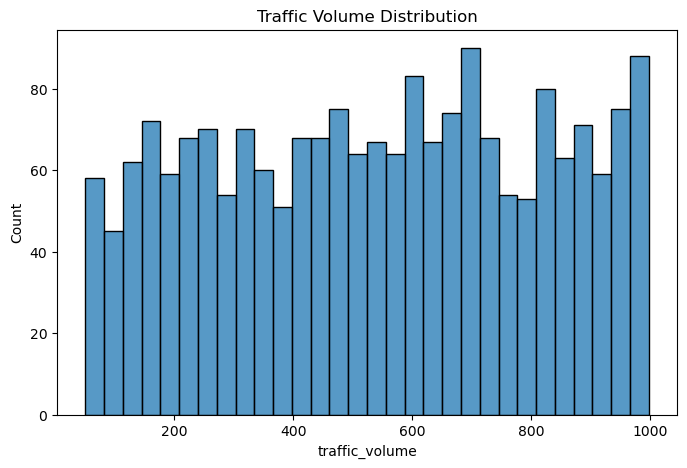

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(traffic_df['traffic_volume'], bins=30)
plt.title("Traffic Volume Distribution")
plt.show()

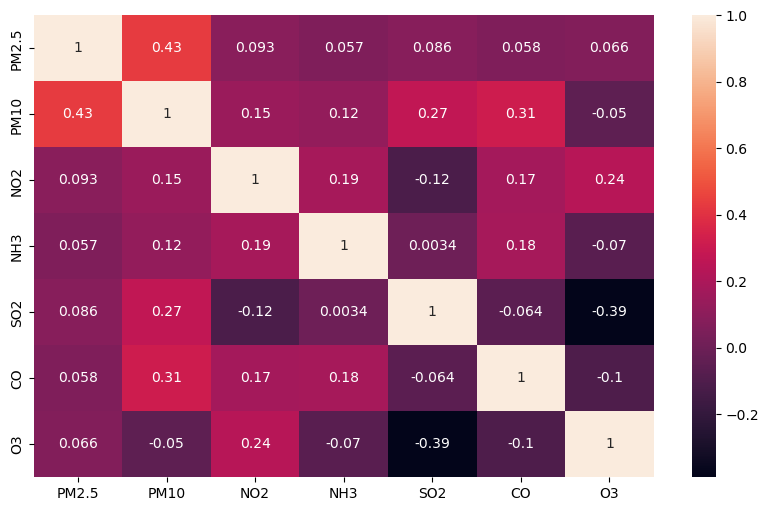

In [16]:
numeric_df = pollution_df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

In [17]:
traffic_df.to_csv(r"C:\Users\Varun Raghu\ENGINEERING NOTES\Data Analyst\Internship Project Data Analytics\cleaned_traffic.csv", index=False)


In [18]:
pollution_df.to_csv(r"C:\Users\Varun Raghu\ENGINEERING NOTES\Data Analyst\Internship Project Data Analytics/cleaned_pollution.csv", index=False)

In [19]:
traffic_df['timestamp'] = pd.to_datetime(traffic_df['timestamp'])

In [20]:
traffic_df['hour'] = traffic_df['timestamp'].dt.hour

## Insight: Peak Hour Traffic

The analysis shows that traffic volume increases significantly during peak office hours. This indicates higher congestion during morning and evening commuting periods.

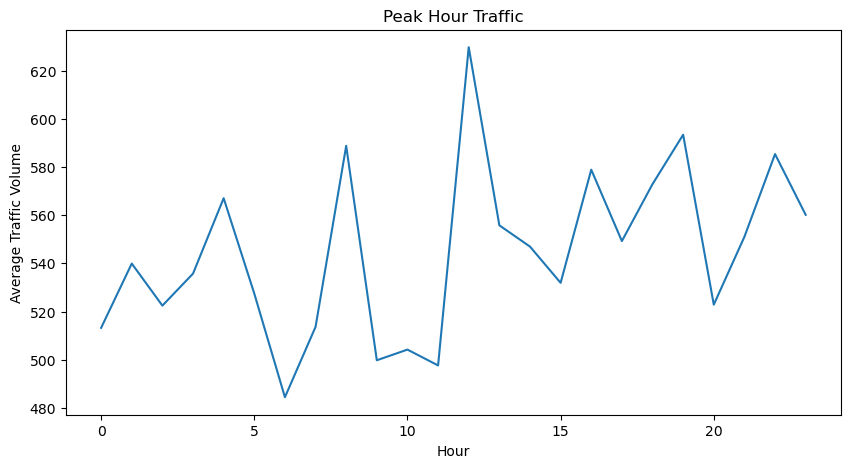

In [21]:
traffic_df.groupby('hour')['traffic_volume'].mean().plot(figsize=(10,5))

plt.title("Peak Hour Traffic")
plt.xlabel("Hour")
plt.ylabel("Average Traffic Volume")

plt.show()

In [22]:
traffic_df.columns

Index(['timestamp', 'location_id', 'traffic_volume', 'avg_vehicle_speed',
       'vehicle_count_cars', 'vehicle_count_trucks', 'vehicle_count_bikes',
       'weather_condition', 'temperature', 'humidity', 'accident_reported',
       'signal_status', 'hour'],
      dtype='object')

## Insight: Vehicle Distribution

Cars contribute the highest share of traffic volume compared to trucks and bikes. Heavy vehicle density directly impacts congestion levels.

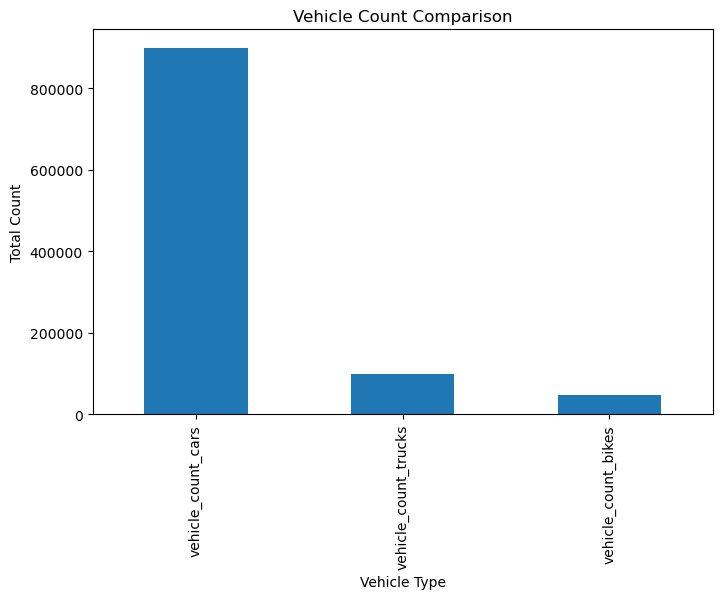

In [23]:
vehicle_data = traffic_df[['vehicle_count_cars',
                           'vehicle_count_trucks',
                           'vehicle_count_bikes']].sum()

vehicle_data.plot(kind='bar', figsize=(8,5))

plt.title("Vehicle Count Comparison")
plt.xlabel("Vehicle Type")
plt.ylabel("Total Count")

plt.show()

## Insight: Pollutant Comparison

PM2.5 and PM10 are among the most dominant pollutants observed in the dataset. These pollutants significantly affect environmental and public health conditions.

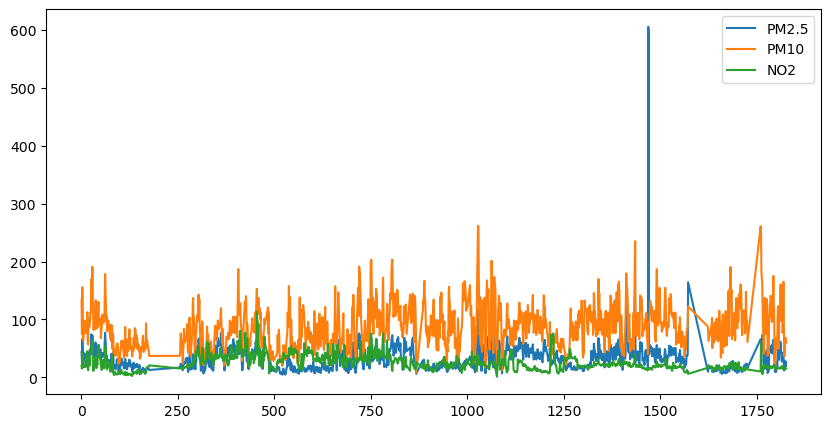

In [24]:
pollution_df[['PM2.5','PM10','NO2']].plot(figsize=(10,5))
plt.show()

## Insight: Weather Impact on Traffic

Weather conditions influence traffic movement and average vehicle speed. Poor weather conditions can lead to slower traffic flow and increased congestion.

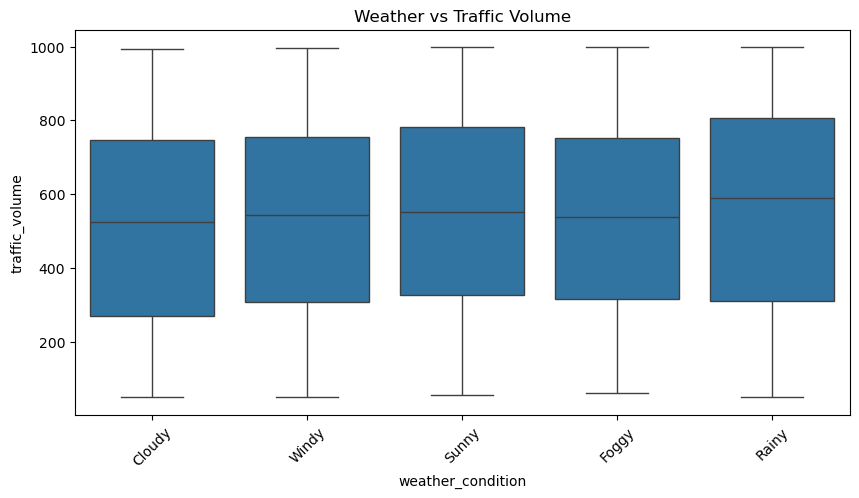

In [25]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='weather_condition',
    y='traffic_volume',
    data=traffic_df
)

plt.xticks(rotation=45)

plt.title("Weather vs Traffic Volume")

plt.show()

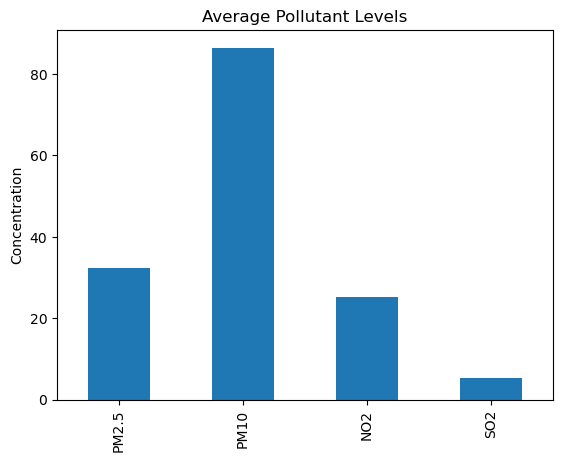

In [26]:
pollution_df[['PM2.5','PM10','NO2','SO2']].mean().plot(kind='bar')

plt.title("Average Pollutant Levels")

plt.ylabel("Concentration")

plt.show()

In [27]:
pollution_df.columns

Index(['Timestamp', 'Location', 'PM2.5', 'PM10', 'NO2', 'NH3', 'SO2', 'CO',
       'O3'],
      dtype='object')

# Combined Insights

The combined traffic and pollution analysis suggests that:
- Heavy traffic congestion contributes to increased pollution levels.
- Peak traffic periods may lead to higher emissions.
- Weather conditions affect both traffic flow and pollution behavior.
- Better traffic management strategies can help reduce environmental pollution.

# Conclusion

This project successfully analyzed traffic and pollution datasets using data analytics techniques. The study identified traffic congestion patterns, pollutant behavior, and environmental trends through visualizations and statistical analysis.

The project demonstrates how data analytics can support smart city planning, traffic optimization, and environmental monitoring.

# Future Scope

Future improvements can include:
- Real-time traffic monitoring
- AQI prediction using machine learning
- Smart traffic signal optimization
- Integration with IoT sensors
- Real-time dashboard deployment

In [28]:
traffic_df.to_csv(r"C:\Users\Varun Raghu\ENGINEERING NOTES\Data Analyst\Internship Project Data Analytics\Newcleaned_traffic.csv", index=False)


In [30]:
pollution_df.to_csv(r"C:\Users\Varun Raghu\ENGINEERING NOTES\Data Analyst\Internship Project Data Analytics/newcleaned_pollution.csv", index=False)